Introduction & Configuration <br>
This cell sets up our paths and parameters. We define the paths based on your previous messages. We also set the device to 'cuda' to utilize your RTX 4070 Ti.

In [2]:
import os
import torch
import cv2
import numpy as np
import collections
import random
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# The Base Path to your AMI Traps dataset
BASE_DIR = r"C:\Users\ruben\Downloads\Archive\ami_traps\ami_traps_dataset"
IMAGES_DIR = os.path.join(BASE_DIR, "images")
LABELS_DIR = os.path.join(BASE_DIR, "labels")

# Hyperparameters
BATCH_SIZE = 2      # Low batch size for RTX 4070 Ti (Faster R-CNN is heavy)
NUM_EPOCHS = 10     # Adjust as needed
LEARNING_RATE = 0.005
MIN_SAMPLES = 50    # Minimum labels required to include a class

# Setup Device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Active Device: {device}")
print(f"Images Path: {IMAGES_DIR}")

Active Device: cuda
Images Path: C:\Users\ruben\Downloads\Archive\ami_traps\ami_traps_dataset\images


Dataset Class (Logic Fix) <br>
This class reads your specific folder structure. It filters out insects that are too rare (< 50 examples) and converts the bounding box coordinates from YOLO format (0-1 relative) to Pascal VOC format (absolute pixels) required by Faster R-CNN.

In [3]:
class AmiTrapsDataset(Dataset):
    def __init__(self, img_dir, label_dir, min_samples=50):
        self.img_dir = img_dir
        self.label_dir = label_dir
        
        # 1. Gather all files and count classes
        self.all_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
        self.valid_files = []
        
        # Count occurrences of every class ID
        class_counts = collections.defaultdict(int)
        
        print("Scanning dataset classes...")
        for file in self.all_files:
            # Check if corresponding image exists
            img_name = file.replace('.txt', '.jpg')
            if not os.path.exists(os.path.join(img_dir, img_name)):
                continue
                
            with open(os.path.join(label_dir, file), 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if line.strip():
                        cls_id = int(line.split()[0])
                        class_counts[cls_id] += 1

        # 2. Determine valid classes (>= min_samples)
        self.valid_classes = [c for c, count in class_counts.items() if count >= min_samples]
        self.valid_classes.sort()
        
        # Create mapping: Real ID -> 1, 2, 3... (0 is background)
        self.map_id_to_idx = {real_id: i+1 for i, real_id in enumerate(self.valid_classes)}
        self.map_idx_to_id = {i+1: real_id for i, real_id in enumerate(self.valid_classes)}
        
        print(f"Found {len(class_counts)} raw classes.")
        print(f"Keeping {len(self.valid_classes)} classes with >= {min_samples} samples.")
        print(f"Class Map (Internal Index -> Real ID): {self.map_idx_to_id}")

        # 3. Filter files that contain at least one valid object
        for file in self.all_files:
            has_valid_obj = False
            path = os.path.join(label_dir, file)
            with open(path, 'r') as f:
                for line in f:
                    if line.strip():
                        cls_id = int(line.split()[0])
                        if cls_id in self.valid_classes:
                            has_valid_obj = True
                            break
            if has_valid_obj:
                self.valid_files.append(file)
                
        print(f"Training on {len(self.valid_files)} valid images.")

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        label_file = self.valid_files[idx]
        img_file = label_file.replace('.txt', '.jpg')
        
        img_path = os.path.join(self.img_dir, img_file)
        label_path = os.path.join(self.label_dir, label_file)
        
        # Load Image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        img_tensor = F.to_tensor(img)
        
        boxes = []
        labels = []
        
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                
                cls_id = int(parts[0])
                if cls_id in self.valid_classes:
                    # YOLO (x_c, y_c, w, h) -> VOC (x1, y1, x2, y2)
                    bx = float(parts[1]) * w
                    by = float(parts[2]) * h
                    bw = float(parts[3]) * w
                    bh = float(parts[4]) * h
                    
                    x1 = bx - bw/2
                    y1 = by - bh/2
                    x2 = bx + bw/2
                    y2 = by + bh/2
                    
                    boxes.append([x1, y1, x2, y2])
                    labels.append(self.map_id_to_idx[cls_id])
        
        # Convert to Torch Tensors
        target = {}
        target["boxes"] = torch.as_tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.as_tensor(labels, dtype=torch.int64)
        target["image_id"] = torch.tensor([idx])
        
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

Cell A: Initialize Data and Split <br>
Since we only have one folder, we split it here into 80% Training and 20% Validation.

In [4]:
# Create Full Dataset
full_dataset = AmiTrapsDataset(IMAGES_DIR, LABELS_DIR, min_samples=MIN_SAMPLES)

# Split into Train (80%) and Test (20%)
indices = torch.randperm(len(full_dataset)).tolist()
split_idx = int(0.8 * len(full_dataset))

train_dataset = Subset(full_dataset, indices[:split_idx])
test_dataset = Subset(full_dataset, indices[split_idx:])

# Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)} | Test images: {len(test_dataset)}")

Scanning dataset classes...
Found 722 raw classes.
Keeping 40 classes with >= 50 samples.
Class Map (Internal Index -> Real ID): {1: 1099, 2: 1138, 3: 1808, 4: 1912, 5: 2351, 6: 2357, 7: 2358, 8: 2392, 9: 2501, 10: 2790, 11: 2991, 12: 2997, 13: 3031, 14: 3652, 15: 3694, 16: 3852, 17: 4774, 18: 5112, 19: 5121, 20: 5800, 21: 5920, 22: 5953, 23: 5981, 24: 6315, 25: 6714, 26: 7069, 27: 7243, 28: 7504, 29: 7541, 30: 7575, 31: 8083, 32: 8133, 33: 8134, 34: 9409, 35: 9826, 36: 10175, 37: 10896, 38: 10901, 39: 11077, 40: 11304}
Training on 2500 valid images.
Train batches: 1000 | Test images: 500


Setup Model and Optimizer

In [7]:
# 0 = Background, + N insect classes
num_classes = len(full_dataset.valid_classes) + 1 

# Load Pre-trained Faster R-CNN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Replace the Head for our specific number of insects
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)

# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\ruben/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:04<00:00, 34.5MB/s] 


Training Process <br>
This loop trains the model. It includes error handling for "empty" images (images where insects were filtered out due to low counts).

In [ ]:
loss_history = []

print(f"Starting Training on {len(train_loader)} batches...")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    i = 0
    
    prog_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for images, targets in prog_bar:
        # Move to GPU
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Skip images that ended up empty after filtering
        if len(targets) == 0 or len(targets[0]['boxes']) == 0:
            continue

        # Forward Pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward Pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        i += 1
        prog_bar.set_postfix(loss=losses.item())
        
    lr_scheduler.step()
    
    # Calculate and store average loss for this epoch
    if i > 0:
        avg_loss = epoch_loss / i
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1} done. Avg Loss: {avg_loss:.4f}")
    else:
        print(f"Epoch {epoch+1} skipped (no valid batches).")

# --- SAVE MODEL ---
save_path = os.path.join(os.getcwd(), "faster_rcnn_ami_traps.pth")
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

# --- PRINT CLASS MAPPING ---
print("="*30)
print("COPY THIS DICTIONARY FOR APP.PY:")
print(full_dataset.map_idx_to_id)
print("="*30)

# --- PLOT TRAINING LOSS ---
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss', color='tab:blue', linewidth=2)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Starting Training...


Epoch 1: 100%|██████████| 1000/1000 [06:01<00:00,  2.77it/s, loss=0.553]


Epoch 1 done. Avg Loss: 0.9419


Epoch 2: 100%|██████████| 1000/1000 [05:42<00:00,  2.92it/s, loss=1.2] 


Epoch 2 done. Avg Loss: 0.7322


...

Epoch 8 done. Avg Loss: 0.4782


Epoch 9: 100%|██████████| 1000/1000 [05:29<00:00,  3.04it/s, loss=0.453]


Epoch 9 done. Avg Loss: 0.4763


Epoch 10: 100%|██████████| 1000/1000 [05:27<00:00,  3.05it/s, loss=0.106]

Epoch 10 done. Avg Loss: 0.4760
Model saved to: r:\Files Ruben\GitRepos\InsectRecognizerAI\notebook\Faster R-CNN\faster_rcnn_ami_traps.pth
COPY THIS DICTIONARY FOR APP.PY:
{1: 1099, 2: 1138, 3: 1808, 4: 1912, 5: 2351, 6: 2357, 7: 2358, 8: 2392, 9: 2501, 10: 2790, 11: 2991, 12: 2997, 13: 3031, 14: 3652, 15: 3694, 16: 3852, 17: 4774, 18: 5112, 19: 5121, 20: 5800, 21: 5920, 22: 5953, 23: 5981, 24: 6315, 25: 6714, 26: 7069, 27: 7243, 28: 7504, 29: 7541, 30: 7575, 31: 8083, 32: 8133, 33: 8134, 34: 9409, 35: 9826, 36: 10175, 37: 10896, 38: 10901, 39: 11077, 40: 11304}


Training Loss Curve <br>
Explanation <br>
This cell visualizes the loss_history variable that was populated during the training loop. This graph is crucial to check if your model actually learned anything. <br>
Decreasing trend: The model is learning. <br>
Flat line: The model is not learning (check learning rate). <br>
Spikes: Batch size might be too small or learning rate too high. <br>

⚠️ Training history not found in memory (Kernel restarted?).
Calculating current loss on Test Dataset instead...


Validating: 100%|██████████| 500/500 [00:57<00:00,  8.70it/s]


✅ Current Model Loss on Test Data: 0.5993


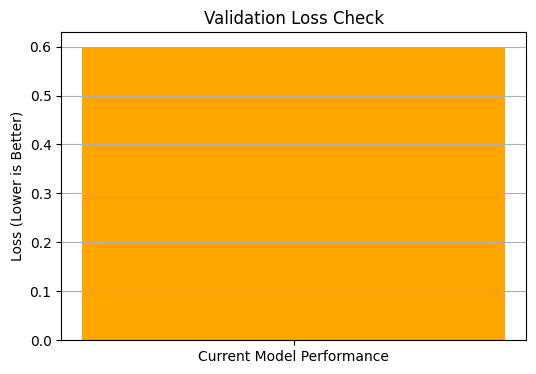

In [13]:
# Check if training history exists in memory
if 'loss_history' in locals() and len(loss_history) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history, label='Training Loss', color='blue', linewidth=2)
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()
else:
    print("⚠️ Training history not found in memory (Kernel restarted?).")
    print("Calculating current loss on Test Dataset instead...")
    
    # Calculate loss on Test Set now
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Validating"):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # We must temporarily set model to train mode to get loss values from PyTorch Faster-RCNN
            model.train() 
            loss_dict = model(images, targets)
            model.eval() # Switch back
            
            losses = sum(loss for loss in loss_dict.values())
            test_loss += losses.item()
            
    avg_test_loss = test_loss / len(test_loader)
    print(f"\n✅ Current Model Loss on Test Data: {avg_test_loss:.4f}")
    
    # Visual bar for context
    plt.figure(figsize=(6, 4))
    plt.bar(['Current Model Performance'], [avg_test_loss], color='orange')
    plt.ylabel('Loss (Lower is Better)')
    plt.title('Validation Loss Check')
    plt.grid(axis='y')
    plt.show()

Visualization 2: Verify Ground Truth Data (What the AI sees) <br>
Explanation <br>
This cell picks a random image from your dataset object, draws the "Ground Truth" (correct) bounding boxes on it, and displays it. This is a sanity check to ensure your YOLO -> Pascal VOC conversion logic was correct and the boxes align perfectly with the insects. <br>

Viewing Image ID: 1583 | Total Objects: 17


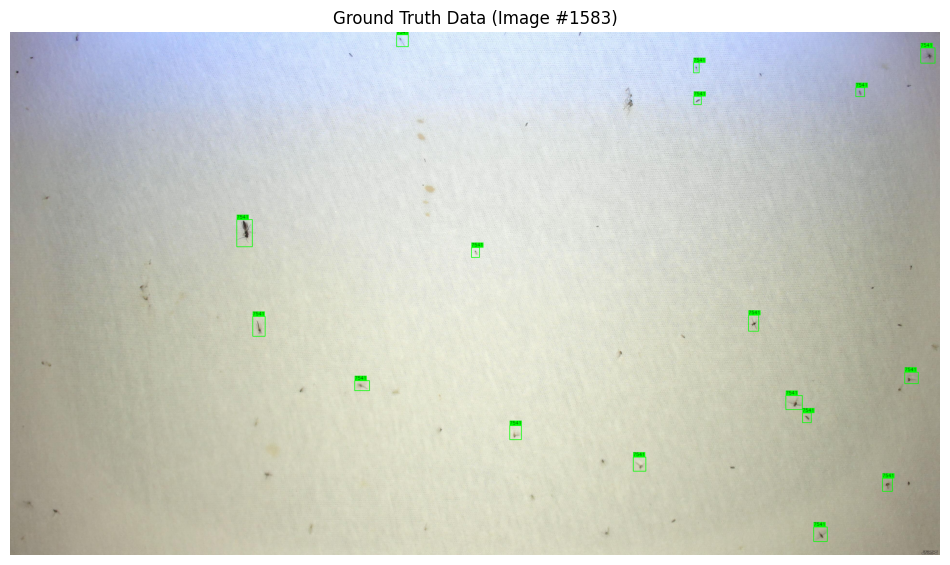

In [11]:
def visualize_ground_truth(dataset, index=None):
    # Pick random index if not provided
    if index is None:
        index = random.randint(0, len(dataset)-1)
    
    img_tensor, target = dataset[index]
    
    # Prepare image for plotting (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.ascontiguousarray(img_np) # Fix memory layout for cv2
    img_display = img_np.copy()
    
    # Get boxes and labels
    boxes = target['boxes'].cpu().numpy()
    labels = target['labels'].cpu().numpy()
    
    print(f"Viewing Image ID: {index} | Total Objects: {len(boxes)}")
    
    for box, label_idx in zip(boxes, labels):
        x1, y1, x2, y2 = box.astype(int)
        
        # Get Real ID name (e.g., 2351)
        class_id = dataset.map_idx_to_id[label_idx]
        
        # Draw Rectangle (Green for Ground Truth)
        cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 1, 0), 2)
        
        # Draw Label background
        text = str(class_id)
        (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(img_display, (x1, y1 - 20), (x1 + w, y1), (0, 1, 0), -1)
        cv2.putText(img_display, text, (x1, y1 - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_display)
    plt.title(f"Ground Truth Data (Image #{index})")
    plt.axis('off')
    plt.show()

# Run visualization
visualize_ground_truth(full_dataset)

Visualization 3: Model Predictions on Test Data <br>
Explanation <br>
This is the most important visualization. It takes an image from the Test Dataset (images the model has never seen before), feeds it into the trained model, and draws the predicted boxes. <br>
Score Threshold: We filter out boxes where the model is less than 50% confident (score < 0.5). <br>
Red Boxes: These are the AI's predictions. <br>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Predicting on Test Image #101...


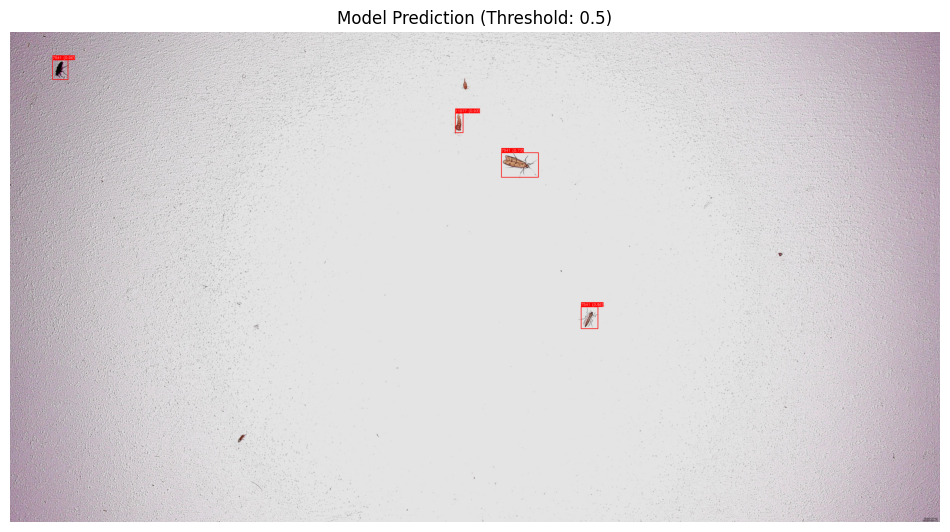

In [12]:
def visualize_prediction(model, dataset, device, threshold=0.5):
    # Set model to evaluation mode
    model.eval()
    
    # Pick random test image
    idx = random.randint(0, len(dataset)-1)
    img_tensor, _ = dataset[idx]
    
    # Pass through model
    with torch.no_grad():
        # Add batch dimension [1, C, H, W] and send to GPU
        prediction = model([img_tensor.to(device)])[0]
    
    # Prepare image for display
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_display = img_np.copy()
    
    # Parse predictions
    pred_boxes = prediction['boxes'].cpu().numpy()
    pred_scores = prediction['scores'].cpu().numpy()
    pred_labels = prediction['labels'].cpu().numpy()
    
    print(f"Predicting on Test Image #{idx}...")
    
    found_any = False
    
    for box, score, label_idx in zip(pred_boxes, pred_scores, pred_labels):
        if score > threshold:
            found_any = True
            x1, y1, x2, y2 = box.astype(int)
            
            # Get Real Class ID (using the full_dataset mapping)
            # Note: We access the parent dataset to get the map
            class_id = full_dataset.map_idx_to_id.get(label_idx, "Unknown")
            
            # Draw Red Box for Prediction
            cv2.rectangle(img_display, (x1, y1), (x2, y2), (1, 0, 0), 2)
            
            # Label Text
            text = f"{class_id} ({score:.2f})"
            (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(img_display, (x1, y1 - 20), (x1 + w, y1), (1, 0, 0), -1)
            cv2.putText(img_display, text, (x1, y1 - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    if not found_any:
        print("No insects detected above threshold.")

    plt.figure(figsize=(12, 8))
    plt.imshow(img_display)
    plt.title(f"Model Prediction (Threshold: {threshold})")
    plt.axis('off')
    plt.show()

# Run prediction visualization on the test_dataset
visualize_prediction(model, test_dataset, device, threshold=0.5)